## Make a figure showing all GHG data 
#### Including a fit a curve with the NOAA method
#### Including a seasonal cycle


The NOAA method for curve fitting used is described here: 

The method is described: https://gml.noaa.gov/ccgg/mbl/crvfit/crvfit.html 

The code is available at: https://gml.noaa.gov/aftp/user/thoning/ccgcrv/

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot

import matplotlib.ticker as ticker
import numpy as np
import xarray as xr
import sys
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime as dt

import numpy as np
import itertools
import matplotlib.dates as mdates
import matplotlib.lines as mlines

## Add parent directory to syspath
parent_dir = os.path.abspath(os.path.join(os.path.dirname('.'), '..'))
if not parent_dir in sys.path:
    sys.path.append(parent_dir)
    

from utils.utilities import find_best_grid_point, get_station_coords,form_xdate, get_anomalies
from plotting import tol_colors # color schemes from https://personal.sron.nl/~pault/
from utils import process_data
from utils.ccg_filter import ccg_filter as ccgfilt
from utils.ccg_filter import ccg_dates
from utils import run_curve_fit

#activate interactive figures
%matplotlib widget
#activate autoreload
%load_ext autoreload


from input.read_wdc_data import AvailableData, create_data_reader
#save figures in...
dir_save = '../output/timeseries/'

dir_save_cams = '../output/cams/'

### First, read in all the GHG data

In [2]:
## Read all data
%autoreload 2
from input.read_wdc_data import AvailableData, create_data_reader

# File path
data_path = "../../data/"

# if New data is added to ./data folder, adapt the dictionary in AvailableData
all_data = list(AvailableData)
print(all_data)

#####---------- TO ADAPT ---------------#####
selected_data = ['CO2', 'CO2_flask', 
                 'CO', 'CO_flask', 
                 'CH4', 'CH4_flask', 
                 'O3'
                 ] # define data to read in. If empty, all data is used 
## 
processing_kwargs = { 
    'FLASK_FLAG_CORR' : True # exclude flagged flask-data
}
#####-----------------------------------#####

datasets = [] # initialize list of all datasets 
# read in data
for sel in (selected_data if selected_data else all_data):
    #define where the data has to be read from
    data_reader =  create_data_reader(data_path=data_path,dataset=sel,**processing_kwargs) #creates an instance of the desired data_reader class
    print(f"Data from {data_reader.__class__.__name__} for {sel}:")

    # call the data-reading function on that instance: 
    data = data_reader.read_data() 
    # call the data-processing
    data = data_reader.process_data(data)

    # prepare merged dataset
    data = data.drop(columns='endtime') # problem when merging datasets (because of NaT?), so better remove endtime
    ds = data.to_xarray()
    ds = ds.assign_coords(dataset=sel)
    ds['species'] = data_reader.species
    ds['unit']  = np.unique(ds.unit.dropna(dim='time'))[0]
    datasets.append(ds)

# save all in one xarray dataset
ds_all = xr.concat(datasets,dim="dataset")


['CO2', 'CO2_flask', 'CO', 'CO_flask', 'CO_2002-2006', 'CH4', 'CH4_flask', 'O3', 'aerosols_2015', 'aerosols', 'other_gases_ebas', 'other_gases_wdc', 'meteo']
Data from wdcGHGReader for CO2:
Data from wdcFlaskReader for CO2_flask:
Data from wdcGHGReader for CO:
Data from wdcFlaskReader for CO_flask:
Data from wdcGHGReader for CH4:
Data from wdcFlaskReader for CH4_flask:
Data from ebasReader for O3:


#### Remove outlies (e.g. CO peak)

In [3]:
sel_species = ds_all.species
unique_species = np.unique(sel_species)
species_sel = unique_species

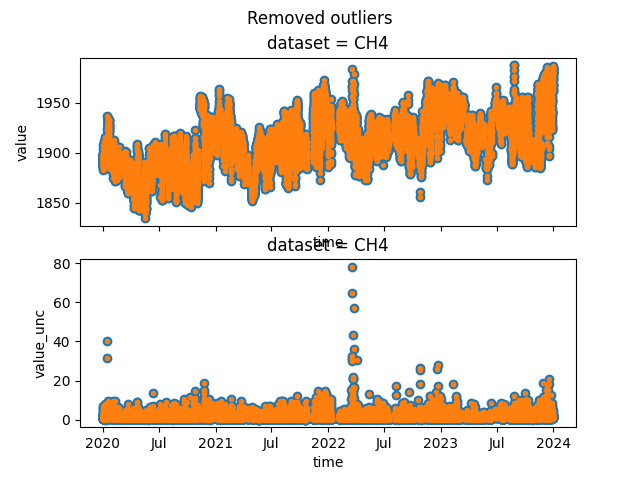

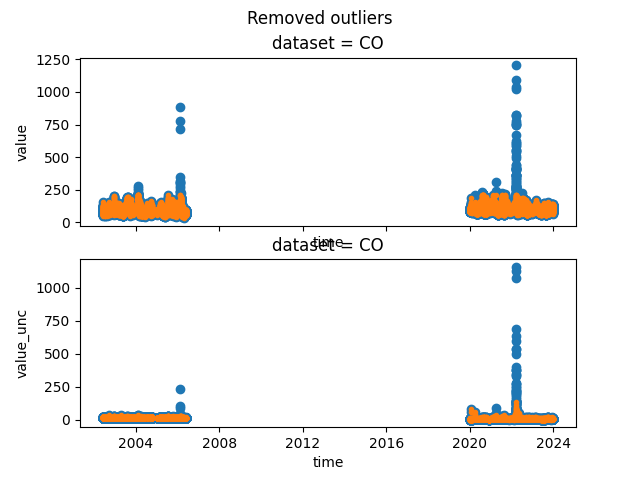

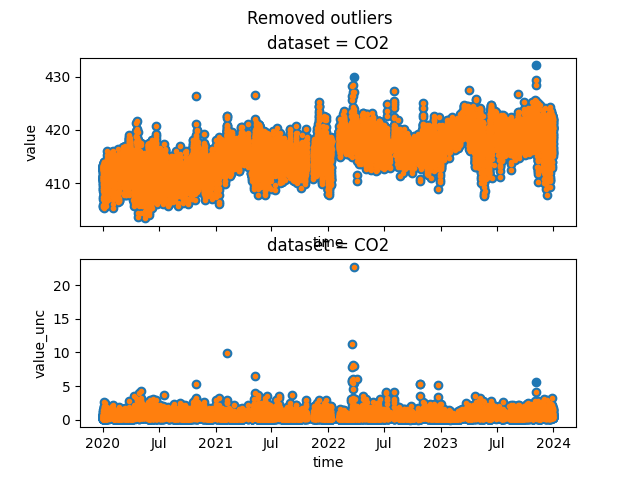

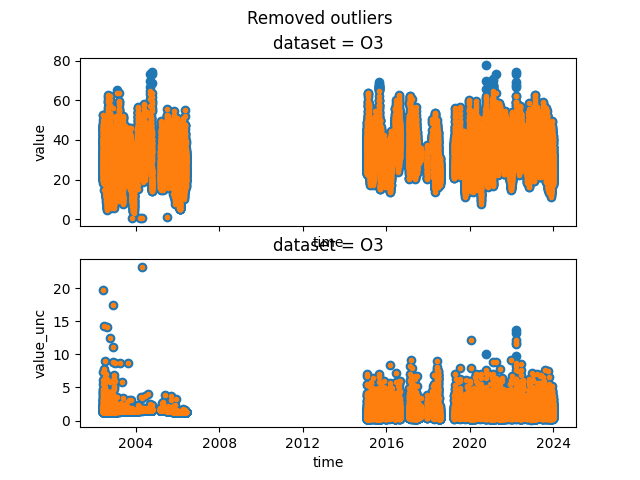

In [4]:
# Remove outliers that exceed 10*stdedeviation and 4* the zscore (see )
ds_all_rem_out = process_data.rem_out(ds_all, std_fac=10, z_threshold=4)

## shouldnt it be like this???
# ds_all_rem_out = ds_all.copy()
# for ds in species_sel:
#     print(f"remove outliers for {ds}")
#     ds_all_rem_out.loc[dict(dataset=ds)] = process_data.rem_out(ds_all.sel(dataset=ds), std_fac=10, z_threshold=4)

# plot removed data
var = "value"
for s in species_sel:
    fig, axs = plt.subplots(2, 1, sharex=True)
    fig.suptitle("Removed outliers")
    ds_all.sel(dataset=s)[var].plot(ls="", marker="o", ax=axs[0])
    ds_all.sel(dataset=s)[var + "_unc"].plot(ls="", marker="o", ax=axs[1])
    # new data:
    ds_all_rem_out.sel(dataset=s)[var].plot(ls="", marker=".", ax=axs[0])
    ds_all_rem_out.sel(dataset=s)[var + "_unc"].plot(ls="", marker=".", ax=axs[1])
    plt.show()


#### Prepare the figure

In [ ]:
## Define the data periods I want to compare/plot ##! TP ADAPT!

t0 = ds_all.isel(time=0)
t1 = ds_all.isel(time=-1)
print(f"Total time period with data:: {t0.time.values} to {t1.time.values}")

compare_periods = {
    'A': (t0.time.values, dt.datetime(2006,12,31)), #old and flask data
    'B': (dt.datetime(2008,1,1), dt.datetime(2011,12,31)), #only flask data
    #'C0': (dt.datetime(2020,1,1), t1.time.values), # only new data
    'C': (dt.datetime(2014,1,1), t1.time.values) # only ozone data
}

In [ ]:
# Define fit paramaters for the curve fitting
# Default values
fit_params_defaults = {'shortterm': 80, #Short term cutoff value in days for smoothing of data
                'longterm': 667, # smoothing in days. Default: 667
                'numpolyterms': 2, # use only 2 for less than 3 years of data, otherwise use 3 (=quadratic fit)
                'sampleinterval': 1 / 24,  # 1h
                'numharmonics': 4}

fit_properties = {}
for dataset in ds_all.dataset:
    dataset_name = dataset.values.item()  # Convert numpy array to a hashable type
    fit_properties[dataset_name] = fit_params_defaults.copy()
    
# Update fit_properties with non-default values if necessary:
# Remove sampleinterval for flask data:
for dataset in fit_properties:
    if '_flask' in dataset:
        fit_properties[dataset]['sampleinterval'] = 0 #if 0, determine from xp (time)

#fit_properties['CO']['numpolyterms'] = 3


In [ ]:
## Helper functions for the figure

import matplotlib.colors as mc
from labellines import labelLine, labelLines
import colorsys 

# adjust the lightness of a color
def adjust_lightness(color, amount=0.5):
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], max(0, min(1, amount * c[1])), c[2])

# function to plot each subplot
# time series plot
def plot_data(ds_temp, ds_temp_fit, label,ax=None, detrend=False, plot_measurements=True, plot_fit=True, **kwargs):
    ''' 
    Plot the data and the fit
    detrend: if True, plot the detrended data
    '''
    if ax is None:
        ax = plt.gca()

    ## get initial figure properties
    initial_color = kwargs['color']
    initial_ls = kwargs['ls']
    
    if plot_measurements:
        kwargs['ls'] = '' #no line for measurements
        pl = ds_temp.plot(
            ax=ax,
            alpha=0.7,
            label=label[0:4],
            #markeredgewidth=0,
            **kwargs
        )
    else:
        pl = []
    #plot fit
    if plot_fit:
        kwargs['color'] = adjust_lightness(initial_color,amount=1.5) # adapt hue of initial color (lighter)
        kwargs['marker'] = '' #no marker for fit
        kwargs['ls'] = initial_ls
        pl_fit = ds_temp_fit["smoothed_vals"].plot(ax=ax, label=label, **kwargs)
        if detrend:
            #plot detrended fit
            kwargs['color'] = adjust_lightness(initial_color,amount=0.8)  # adapt hue of initial color (darker)
            kwargs['ls'] = ':' #dotted line for detrended
            ax.plot(
                ds_temp_fit.time,
                ds_temp_fit["seasonal_detrend"] + ds_temp_fit["smoothed_vals"].mean(),
                label="detrended fit",
                **kwargs,
            )  ## Add mean value to detrended to obtain same magnitude
    else:
        pl_fit = []
    return pl, pl_fit

# seasonality plot
def plot_cycle(ds_temp, ds_temp_fit, s, freq="month", ax=None, with_trend = False, label='', **kwargs):
    '''
    Plot seasonal cycle of the data
    with_trend:  if True, plot the seasonal cycle with trend (non-detrended)
    '''
    
    ## get a different hue of the color used
    # Decrease the hue value
    initial_color = kwargs['color']
    
    if ax is None:
        ax = plt.gca()
    ref = (
        ds_temp.mean()
    )  # use mean value from measurements to obtain positive/neg. seasonality (ds_temp-ref) or absolute values (ds_temp_fit +ref)
    if freq=='hour':
        kwargs['color'] = adjust_lightness(initial_color,amount=1.5)  # adapt hue of initial color (lighter)
        pl = (ds_temp-ref).groupby(f"time.{freq}").mean().plot(
            ax=ax, label=f"{label}",**kwargs
        )
    else:
        # normal seasonal cycle
        if with_trend:
            kwargs['ls'] = ':' #dotted line for not detrended
            kwargs['color'] = adjust_lightness(initial_color,amount=0.8) # adapt hue of initial color (darker)
            #plot also the normal seasonal cycle (with trend)
            (ds_temp-ref).groupby(f"time.{freq}").mean().plot(ax=ax, label=f"{label} not detrended",**kwargs)
        # detrended seasonal cycle
        kwargs['color'] = adjust_lightness(initial_color,amount=1.5)  # adapt hue of initial color (lighter)
        pl = ds_temp_fit["seasonal_detrend"].groupby(f"time.{freq}").mean().plot(
            ax=ax, label=f"{label}", **kwargs
        ) #label=f"{label} detrended"
    return pl


In [ ]:
%autoreload 2

# species to plot
my_species = [ 'CO2', 'CH4', 'CO', 'O3']
#my_species = [ 'CO']
# dataset to use:
# ds_data = ds_all #normal measurement data
ds_data = ds_all_rem_out  # use data with removed outliers!!
#ds_data = ds_all_rem_out.sel(dataset=['CO','CO_flask'])#for debugging
# only select data where the species is in my_species:
ds_data = ds_data.where(ds_data.species.isin(my_species), drop=True)

##---- Plotting definitions ----##
save_fig = True
# plot seasonal or daily cycles
plot_seas = True #if false, plot daily cycle instead of seasonal
seas_freq = 'month' # 'month' or 'dayofyear'
with_trend = False #if true, plot detrended data, otherwise detrend seasonal cycle but dont plot it as extra line in the time series plot

default_colors = ['C2', 'C1', 'C0', 'C3'] if len(compare_periods) >2 else ['C0', 'C1', 'C2', 'C3'] # make third period blue
#default_colors = ['C0', 'C0', 'C0', 'C3'] if len(compare_periods) >2 else ['C0', 'C1', 'C2', 'C3'] # make third period blue
color_iterator = itertools.cycle(default_colors)



##--- Start figure  ---##
# Make a mosaic grid, where each subplot is called either the species (e.g. CO2) or the species seasonal cycle (ew.g. CO2_seas)

mosaic_grids =  [[m, m+'_seas']  for m in my_species] # put [] around to start new row
gs_kw = dict(width_ratios=[3, 1]) #column and width ratios
subfig_height = 2.5 if len(my_species) == 1 else 2
fig, axd = plt.subplot_mosaic(mosaic_grids,
                              gridspec_kw=gs_kw, figsize=(8, len(my_species) * subfig_height),
                              layout="constrained")
                              
for period, (start_date, end_date) in compare_periods.items():
    print(f"Period {period}: {start_date} to {end_date}")
    # Filter the data for the current period
    period_data = ds_data.sel(time=slice(start_date, end_date))

    # Define figure properties for this period
    fig_properties = {
        'color': next(color_iterator),
        'marker': '.',
        'ls':'-'
    }

    
    # Write Period A, B and C just below the time axis in the color of the different periods
    # write it on top of the first axis
    ax_sel = axd[my_species[0]] # first subplot
    ax_sel.text(start_date, 400, f'Period {period}',color=fig_properties['color'], ha='left') #, transform=ax_sel.transAxes

    ## Loop through all datasets and plot the data
    for i,dataset in enumerate(period_data.dataset):
        # Get the data for the current dataset and period
        data = period_data.sel(dataset=dataset)["value"]
        species = period_data.sel(dataset=dataset).species.values
        #print(f"Dataset: {dataset.item()}, Species: {species}")

        if data.size > 0 and np.all(np.isnan(data))==False: #if we have data
        
            # Define fit properties for this dataset
            # Perform the curve fitting and obtain the interpolated time axis
            filt, df_interp, ds_interp = run_curve_fit.run_ccgfilter(
                ds=data,
                dataset_str=dataset.item(),
                t1=start_date,
                t2=end_date,
                **fit_properties[dataset.item()]
            )
              
            # Plot the data and the fit
            # adapt figure properties for flask data
            if dataset.item() == 'CO_flask':
                # CO_flask is the only flask data that we have in parallel with continuous measurements
                # Therefore, we plot it with a different marker and linestyle
                fig_properties['marker'] = 'x'
                #fig_properties['color'] = 'lightgrey'
                fig_properties['zorder'] = 5
                fig_properties['ls'] = '--'
            elif '_flask' in dataset.item():
                # different marker for flask measurements
                fig_properties['marker'] = 'x'
            else:
                # normal properties
                fig_properties['marker'] = '.'
                fig_properties['ls'] = '-'

           
            ## Time series figure
            ax_ts = axd[species.item()]
            ## Seasonal cycle figure
            ax_seas = axd[species.item()+'_seas']


            legend_entry = f"curve fit ({fit_properties[dataset.item()]['shortterm']} days)"
            plot_data(data,                       
                      ds_interp,
                      legend_entry, 
                      ax_ts,
                      with_trend
                      ,**fig_properties)

            #plot seasonal cycle
            freq = seas_freq if plot_seas else 'hour' #for seasonal cycle, use 'dayofyear' (smoother line) or 'month', for daily cycle (if plot_seas=False) use 'hour'
            # no markers for seasonal cycle
            fig_properties['marker'] = '' #no marker for seasonal cycle
            pl_seas = pl_cycle = plot_cycle(
                data,
                ds_interp,
                s,
                freq= freq,
                ax=ax_seas,
                with_trend=with_trend,
                label = period,
                **fig_properties
            )


            #---- figure properties ----#

            # axes properties time series
            ax_ts.set_ylabel(f"{species} ({period_data.sel(dataset=dataset).unit.values})")
            #ax_ts.set_xlim(np.array([t1, t2], dtype="datetime64"))
            ax_ts.spines["top"].set_visible(False)
            ax_ts.spines["right"].set_visible(False)
            ax_ts.set_title("")

            if species != my_species[-1]:  # all except lowest axis
                plt.setp(
                    ax_ts.get_xticklabels(), visible=False
                )  # remove xticklabels except for lowest plot
                ax_ts.set_xlabel("")

            # axes properties seasonal cycle
            # ax_seas.set_yticklabels('') #this removes ylabels for both axes! Therefore better use:
            #ax_seas.tick_params(labelleft=False) #I need the labels if I use other units for the seasoal cycle!!
            ax_seas.set_title("")
            ax_seas.set_ylabel("")
            ax_seas.spines["top"].set_visible(False)
            ax_seas.spines["right"].set_visible(False)
            if plot_seas:
                if freq== 'month':
                    months = range(1, 13, 3)
                    ax_seas.set_xticks(
                        months,
                        [dt.datetime.strptime(str(month), "%m").strftime("%b") for month in months],
                    )
                elif freq == 'dayofyear':
                    ax_seas.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
                    ax_seas.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

            #ax_seas.grid(color='lightgrey',zorder=0,axis='x')
            ax_seas.set_axisbelow(False)

            # different for lowest plot
            if species != my_species[-1]:  # all except lowest axis
                plt.setp(
                    ax_seas.get_xticklabels(), visible=False
                )  # remove xticklabels except for lowest plot
                ax_seas.set_xlabel("")

## --- Final figure properties ---##
handles, labels = ax_ts.get_legend_handles_labels()
# manually adapt legend:
labels[0] = "1h data"
ax0 = list(axd.values())[0] #first subplot (upper left)
if with_trend:
    ax0.legend(handles, labels, loc="lower right")
fig.align_ylabels()

# Add a manual legend showing the shape of the dots to the lower left subplot
marker_flask = mlines.Line2D([], [], color='k', marker='x', linestyle='None', label='Flask data')
marker_other = mlines.Line2D([], [], color='k', marker='.', linestyle='None',label='Continuous data')
ax0.legend(handles=[marker_flask,marker_other], loc='upper left')

# Add the legend to the upper right subplot (cycles)
ax_sel = axd[my_species[0] +'_seas']
handles, labels = ax_sel.get_legend_handles_labels()
labelLines(ax_sel.get_lines(), zorder=2.5)
#ax_sel.legend(handles, labels, loc='upper left')

# place title on first axis
ax0.set_title("Mt. Kenya measurements and curve fit", loc="left")
ax1 = list(axd.values())[1] #second subplot (upper right)
if plot_seas:
    tit_right = "Seasonal cycle \n (detrended)"
else:
    tit_right = 'Diurnal cycle'
ax1.set_title(tit_right, loc="center")


# # plot in each subplot a vertical line for the compare_periods (not working yet)
# for ax in axd.values():
#     if '_seas' in ax.get_label():
#         continue
#     else: 
#         for period, (start_date, end_date) in compare_periods.items():
#             ax.axvline(start_date, color='k', linestyle='--', alpha=0.5)
#             ax.axvline(end_date, color='k', linestyle='--', alpha=0.5)
#             # Create a rectangle patch with transparent background
#             #rect = plt.Rectangle((start_date, ax.get_ylim()[0]), end_date - start_date, ax.get_ylim()[1], facecolor=next(color_iterator), edgecolor='none')
#             # Add the rectangle patch to the plot
#             #ax.add_patch(rect)



str_seas = 'seas' if plot_seas else 'daily'
str_trend = '_detrended' if with_trend else ''
str_freq = '_' + seas_freq if plot_seas else ''





# if not all species are plotted: adapt name
if len(my_species) <4:
    str_spec = '_' + ''.join(my_species)
else:
    str_spec = ''
if save_fig:
    plt.savefig(
        f"{dir_save}timeseries_and_{str_seas}{str_freq}_fit{str_trend}_{len(compare_periods)}periods{str_spec}.png", dpi=300
    )

### Do the curve fitting with CAMS data

In [ ]:
## Load the selected cams data at Mt. Kenya
cams_best_grid = xr.open_dataset(f"{data_path}/cams/cams_best_grid_merged_MKN.nc") #selection where 2 invgg periods (different resolution) were merged

## Remove cams products that I don't want to plot
cams_best_grid = cams_best_grid.drop_sel(dataset=["co2_egg4","ch4_egg4"])

In [ ]:
## Define the data periods I want to compare/plot. For this CAMS comparison, it works with the newest data only!

t0 = ds_all.isel(time=0)
t1 = ds_all.isel(time=-1)
print(f"Total time period with data:: {t0.time.values} to {t1.time.values}")

compare_periods = {
    'Recent period': (dt.datetime(2020,1,1), t1.time.values), # only new data
}

In [ ]:
# Define fit paramaters for the curve fitting
# Default values
fit_params_defaults = {'shortterm': 80, #Short term cutoff value in days for smoothing of data
                'longterm': 667, # smoothing in days. Default: 667
                'numpolyterms': 2, # use only 2 for less than 3 years of data, otherwise use 3 (=quadratic fit)
                'sampleinterval': 1 / 24,  # needed for interpolation when data is missing
                'numharmonics': 4}

fit_properties = {}
for dataset in ds_all.dataset:
    dataset_name = dataset.values.item()  # Convert numpy array to a hashable type
    fit_properties[dataset_name] = fit_params_defaults.copy()
    
# # Update fit_properties with non-default values if necessary:
# # Use different sample-interval for ch4 data (6h) -> finally, better interpolate it to 3h in the curve fitting
# for dataset in fit_properties:
#     print(dataset)
#     if 'CH4' in dataset:
#         fit_properties[dataset]['sampleinterval'] = 6 / 24 

In [ ]:
## To be able to compare with CAMS: resample observations

# other option (which is better for the curve fitting approach): interpolate the CAMS data to 1h!

# observational dataset to use:
# ds_data = ds_all #normal measurement data
ds_data_sel = ds_all_rem_out  # use data with removed outliers!!

# remove unnecessary variables for simplication
variables_to_keep = ["time", "dataset", "value", "value_unc", "unit", "species"]
ds_all_simple = ds_data_sel.drop_vars(set(ds_data_sel.variables) - set(variables_to_keep))


# Resample only time-dependent variables
time_dependent_variables = [
    var for var in ds_all_simple.data_vars if "time" in ds_all_simple[var].dims
]
non_time_dependent_variables = [
    var
    for var in ds_all_simple.data_vars
    if var not in time_dependent_variables or not "time"
]

ds_all_3h = (
    ds_all_simple[time_dependent_variables].resample(time="3h").mean(keep_attrs=True)
)
ds_all_6h = (
    ds_all_simple[time_dependent_variables].resample(time="6h").mean(keep_attrs=True)
)
# add non-time dependent variables again
for var in non_time_dependent_variables:
    ds_all_3h[var] = ds_all_simple[var]
    ds_all_6h[var] = ds_all_simple[var]

In [ ]:
my_species

In [ ]:
### Figure to compare cams with newest measurement data, including line fits
# it only works with the newest data from 2020 and not with flask data!
# The reason is because we are looping through the species, so the dataset and sepcies name has to be the same (e.g. 'CO2', the dataset 'CO2_flask' would not work)

%autoreload 2

# species to plot
my_species = [ 'CO2', 'CH4', 'CO', 'O3']
#my_species = [ 'CO']


##---- Plotting definitions ----##
save_fig = True
# plot seasonal or daily cycles
plot_seas = False #if false, plot daily cycle instead of seasonal
seas_freq = 'dayofyear' # 'month' or 'dayofyear'
with_trend = False #if true, plot detrended data, otherwise detrend seasonal cycle but dont plot it as extra line in the time series plot

default_colors = ['C2', 'C1', 'C0', 'C3'] if len(compare_periods) >2 else ['C0', 'C1', 'C2', 'C3'] # make third period blue
color_iterator = itertools.cycle(default_colors)



##--- Start figure  ---##
# Make a mosaic grid, where each subplot is called either the species (e.g. CO2) or the species seasonal cycle (ew.g. CO2_seas)

mosaic_grids =  [[m, m+'_seas']  for m in my_species] # put [] around to start new row
gs_kw = dict(width_ratios=[3, 1]) #column and width ratios
subfig_height = 2.5 if len(my_species) == 1 else 2
fig, axd = plt.subplot_mosaic(mosaic_grids,
                              gridspec_kw=gs_kw, figsize=(8, len(my_species) * subfig_height),
                              layout="constrained")
                              
for period, (start_date, end_date) in compare_periods.items():
    print(f"Period {period}: {start_date} to {end_date}")

    # Define figure properties for this period
    fig_properties = {
        'color': next(color_iterator),
        'marker': '.',
        'ls':'-'
    }

    ## Loop through all species and plot the data
    for i,species in enumerate(my_species):
        # Get the data for the current species and period
        # if species == "CH4":
        #     ds = ds_all_6h  # ch4 has 6h resolution
        # else:
        #     ds = ds_all_3h
        ds = ds_data_sel
            
       # data = data.where(data.species.isin(my_species), drop=True) #select only the species we want to plot
        ds = ds.sel(time=slice(start_date, end_date), dataset=species)
        data = ds["value"] # extract data values

        #------ plot the measurement data ------#
        if data.size > 0 and np.all(np.isnan(data))==False: #if we have data
        
            # Define fit properties for this dataset
            # Perform the curve fitting and obtain the interpolated time axis
            filt, df_interp, ds_interp = run_curve_fit.run_ccgfilter(
                ds=data,
                dataset_str=species,
                t1=start_date,
                t2=end_date,
                **fit_properties[species]
            )
              
            # Plot the data and the fit
           
            ## Time series figure
            ax_ts = axd[species]
            ## Seasonal cycle figure
            ax_seas = axd[species+'_seas']


            legend_entry = f"obs. fit ({fit_properties[species]['shortterm']} days)"
            fig_properties['marker'] = '.'
            fig_properties['color'] = 'C0'
            plot_data(data,                       
                      ds_interp,
                      legend_entry, 
                      ax_ts,
                      with_trend
                      ,**fig_properties)

            #plot seasonal cycle
            freq = seas_freq if plot_seas else 'hour' #for seasonal cycle, use 'dayofyear' (smoother line) or 'month', for daily cycle (if plot_seas=False) use 'hour'
            # no markers for seasonal cycle
            fig_properties['marker'] = '' #no marker for seasonal cycle
            pl_seas = pl_cycle = plot_cycle(
                data,
                ds_interp,
                s,
                freq= freq,
                ax=ax_seas,
                with_trend=with_trend,
                label = 'Obs.',
                **fig_properties
            )


            #---- plot the CAMS data ----#
            
            # Select the corresponding CAMS data
            cams_datasets_sel = [
                cams_sel
                for cams_sel in cams_best_grid.dataset.values
                if f"{species.lower()}_" in cams_sel
            ]
            cams = cams_best_grid.sel(dataset=cams_datasets_sel, time=slice(start_date, end_date))
            data_cams = cams["value"].squeeze()

            # Perform the curve fitting for CAMS data and obtain the interpolated time axis
            filt, df_interp, ds_interp = run_curve_fit.run_ccgfilter(
                ds=data_cams,
                dataset_str=species,
                t1=start_date,
                t2=end_date,
                **fit_properties[species]
            )

            
            fig_properties['color'] = 'C1'
            legend_entry = f"CAMS fit ({fit_properties[species]['shortterm']} days)"
            fig_properties['marker'] = '' #dont show the CAMS markers, show only the fit
            plot_data(data,                       
                      ds_interp,
                      legend_entry, 
                      ax_ts,
                      with_trend
                      ,**fig_properties)

            #plot seasonal cycle
            freq = seas_freq if plot_seas else 'hour' #for seasonal cycle, use 'dayofyear' (smoother line) or 'month', for daily cycle (if plot_seas=False) use 'hour'
            # no markers for seasonal cycle
            fig_properties['marker'] = '.' #no marker for seasonal cycle
            pl_seas = pl_cycle = plot_cycle(
                data_cams,
                ds_interp,
                s,
                freq= freq,
                ax=ax_seas,
                with_trend=with_trend,
                label = 'CAMS',
                **fig_properties
            )


            #---- figure properties ----#

            # axes properties time series
            ax_ts.set_ylabel(f"{species} ({ds.unit.values})")
            #ax_ts.set_xlim(np.array([t1, t2], dtype="datetime64"))
            ax_ts.spines["top"].set_visible(False)
            ax_ts.spines["right"].set_visible(False)
            ax_ts.set_title("")

            if species != my_species[-1]:  # all except lowest axis
                plt.setp(
                    ax_ts.get_xticklabels(), visible=False
                )  # remove xticklabels except for lowest plot
                ax_ts.set_xlabel("")

            # axes properties seasonal cycle
            # ax_seas.set_yticklabels('') #this removes ylabels for both axes! Therefore better use:
            #ax_seas.tick_params(labelleft=False) #I need the labels if I use other units for the seasoal cycle!!
            ax_seas.set_title("")
            ax_seas.set_ylabel("")
            ax_seas.spines["top"].set_visible(False)
            ax_seas.spines["right"].set_visible(False)
            if plot_seas:
                if freq== 'month':
                    months = range(1, 13, 3)
                    ax_seas.set_xticks(
                        months,
                        [dt.datetime.strptime(str(month), "%m").strftime("%b") for month in months],
                    )
                elif freq == 'dayofyear':
                    ax_seas.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
                    ax_seas.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

            #ax_seas.grid(color='lightgrey',zorder=0,axis='x')
            ax_seas.set_axisbelow(False)

            # different for lowest plot
            if species != my_species[-1]:  # all except lowest axis
                plt.setp(
                    ax_seas.get_xticklabels(), visible=False
                )  # remove xticklabels except for lowest plot
                ax_seas.set_xlabel("")

## --- Final figure properties ---##
handles, labels = ax_ts.get_legend_handles_labels()
# manually adapt legend:
#labels[0] = "1h data"
# remove the cams point labels (because I dont show them)
labels = labels[0:2] + labels[3:]
handles = handles[0:2] + handles[3:]
ax0 = list(axd.values())[0] #first subplot (upper left)
ax0.legend(handles, labels, loc="upper left")
fig.align_ylabels()


# Add the legend to the upper right subplot (cycles)
ax_sel = axd[my_species[0] +'_seas']
handles, labels = ax_sel.get_legend_handles_labels()
labelLines(ax_sel.get_lines(), zorder=2.5)
#ax_sel.legend(handles, labels, loc='upper left')

str_seas = 'seas' if plot_seas else 'daily'
str_trend = '_detrended' if with_trend else ''
str_freq = '_' + seas_freq if plot_seas else ''

# place title on first axis
ax0.set_title("Mt. Kenya measurements and curve fit", loc="left")
ax1 = list(axd.values())[1] #second subplot (upper right)
if plot_seas:
    tit_right = f"Seasonal cycle \n {str_trend}"
else:
    tit_right = 'Diurnal cycle'
ax1.set_title(tit_right, loc="center")





# if not all species are plotted: adapt name
if len(my_species) <4:
    str_spec = '_' + ''.join(my_species)
else:
    str_spec = ''
if save_fig:
    plt.savefig(
        f"{dir_save}cams_and_gaw_{str_seas}{str_freq}_fit{str_trend}_{len(compare_periods)}periods{str_spec}.png", dpi=300
    )

## Same but for CAMS aerosol data

In [ ]:
# load cams aerosol data
dir_data_cams = r"../../data/level3/cams"
cams_eac4 = xr.open_dataset(dir_data_cams + r"/cams_eac4_2003_2023_MKN.nc")

In [ ]:
# variables I would like to plot
aerosol_vars = [
    "bcaod550",  # Black Carbon Aerosol Optical Depth at 550nm
    "omaod550",  # Dust Aerosol Optical Depth at 550nm
    ["pm1", "pm2p5","pm10"],  # Particulate matter d <= 10 um
    [
        "aod469",  # Total Aerosol Optical Depth at 469nm
        "aod550",
        "aod670",
        "aod865",
        "aod1240"
    ],
]
my_species = ["BC_AOD", 'OM_AOD', "PM", "AOD"]

In [ ]:
## Select the same grid as for CO -EAC4 data
eac_lat, eac_lon, eac_lev = [
    cams_best_grid.sel(dataset="co_eac4")[var].values
    for var in ["latitude", "longitude", "level"]
]

cams_eac4_sel = cams_eac4.sel(latitude=eac_lat,longitude=eac_lon, level=eac_lev,drop=True)

In [ ]:
# Define fit paramaters for the curve fitting
# Default values
fit_params_aerosols = {'shortterm': 80, #Short term cutoff value in days for smoothing of data
                'longterm': 667, # smoothing in days. Default: 667
                'numpolyterms': 2, # use only 2 for less than 3 years of data, otherwise use 3 (=quadratic fit)
                'sampleinterval': 1 / 24,  # 1h #CHECK : is that correct? Is it interpolating cams data to 1h??
                'numharmonics': 4}

In [ ]:
#redfine figure plotting (slight adaptations compared to before)

# seasonality plot
def plot_cycle2(ds_temp, ds_temp_fit, s, freq="month", ax=None, with_trend = False, label='', **kwargs):
    '''
    Plot seasonal cycle of the data
    with_trend:  if True, plot the seasonal cycle with trend (non-detrended)
    '''
    
    ## get a different hue of the color used
    # Decrease the hue value
    initial_color = kwargs['color']
    
    if ax is None:
        ax = plt.gca()
    ref = (
        ds_temp.mean()
    )  # use mean value from measurements to obtain positive/neg. seasonality (ds_temp-ref) or absolute values (ds_temp_fit +ref)
    if freq=='hour':
        kwargs['color'] = adjust_lightness(initial_color,amount=1.5)  # adapt hue of initial color (lighter)
        pl = (ds_temp-ref).groupby(f"time.{freq}").mean().plot(
            ax=ax, label=f"{label}",**kwargs
        )
    else:
        # normal seasonal cycle
        if with_trend:
            # detrended seasonal cycle 
            kwargs['color'] = adjust_lightness(initial_color,amount=1.5)  # adapt hue of initial color (lighter)
            pl = ds_temp_fit["seasonal_detrend"].groupby(f"time.{freq}").mean().plot(
                ax=ax, label=f"{label}", **kwargs
            ) #label=f"{label} detrended"
        else: #dont show detrended data when with_trend=False
            #kwargs['ls'] = ':' #dotted line for not detrended
            kwargs['color'] = adjust_lightness(initial_color,amount=0.8) # adapt hue of initial color (darker)
            #plot the normal seasonal cycle (not detrended)
            (ds_temp-ref).groupby(f"time.{freq}").mean().plot(ax=ax, label=f"{label} not detrended",**kwargs)
        
    return pl


In [ ]:
import matplotlib as mpl
### Figure to plot cams aerosol data
tsel1 = "2020-01-01"
tsel2 = "2023-12-31"

##---- Plotting definitions ----##
save_fig = True
# plot seasonal or daily cycles
plot_seas = True #if false, plot daily cycle instead of seasonal
seas_freq = 'dayofyear' # 'month' or 'dayofyear'
with_trend = False #if true, plot detrended data, otherwise do not add any detrending (not the same as it was done before)

plot_measurements = False # plot the measurements or only the smoothed liens
legend_on_lines = False # define wether the legend should be seperate or on the lines

#------------------------------  ##

#default_colors = ['C2', 'C1', 'C0', 'C3','C4'] if len(compare_periods) >2 else ['C0', 'C1', 'C2', 'C3'] # make third period blue
default_colors = mpl.colors.TABLEAU_COLORS
#color_iterator = itertools.cycle(default_colors)
# Function to create a new color iterator
def new_color_iterator():
    return itertools.cycle(default_colors)


##--- Start figure  ---##
# Make a mosaic grid, where each subplot is called either the species (e.g. CO2) or the species seasonal cycle (ew.g. CO2_seas)

mosaic_grids =  [[m, m+'_seas']  for m in my_species] # put [] around to start new row
gs_kw = dict(width_ratios=[3, 1]) #column and width ratios
subfig_height = 2.5 if len(my_species) == 1 else 2
fig, axd = plt.subplot_mosaic(mosaic_grids,
                              gridspec_kw=gs_kw, figsize=(8, len(my_species) * subfig_height),
                              layout="constrained")
                              

# Define figure properties
fig_properties = {
    'color': list(default_colors.values())[0], #next(color_iterator),
    'marker': '.',
    'ls':'-'
}

def prepare_and_plot_aerosol_cams(var,ax_ts,ax_seas,**fig_properties):
    
    # Select the corresponding CAMS data
    data_cams = cams_eac4_sel.sel(time=slice(tsel1,tsel2))[var]
    #data_cams = cams["value"].squeeze()
    
    # Perform the curve fitting for CAMS data and obtain the interpolated time axis
    filt, df_interp, ds_interp = run_curve_fit.run_ccgfilter(
        ds=data_cams,
        dataset_str=var,
        t1=start_date,
        t2=end_date,
        **fit_params_aerosols
    )

    #fig_properties['color'] = 'C1'
    #legend_entry = f"{var} fit"
    legend_entry = ''.join(filter(str.isdigit, var)) #only the wavelength
    if var == 'pm2p5':
        legend_entry = '2.5'
    if 'aermr' in var:
        #special legend entries for mixing ratio variables
        legend_entry = legend_entries_mr[var]
    fig_properties['marker'] = '.' #dont show the CAMS markers, show only the fit
    plot_data(data_cams,                       
                ds_interp,
                legend_entry, 
                ax_ts,
                with_trend,
                plot_measurements=plot_measurements, # set to False if the single points should not be plotted
                **fig_properties)

    var_str = ''.join(filter(str.isalpha, var)) #extract letters only from variable name
    ax_ts.set_title('')
    ax_ts.set_title(data_cams.long_name, loc='left') #data_cams.long_name[:-9]
    ax_ts.set_ylabel(f"{var_str.upper()} ({data_cams.units})")

    
    #plot seasonal cycle
    freq = seas_freq if plot_seas else 'hour' #for seasonal cycle, use 'dayofyear' (smoother line) or 'month', for daily cycle (if plot_seas=False) use 'hour'
    # no markers for seasonal cycle
    fig_properties['marker'] = '' #no marker for seasonal cycle
    pl_seas = pl_cycle = plot_cycle(
        data_cams,
        ds_interp,
        s,
        freq= freq,
        ax=ax_seas,
        with_trend=with_trend,
        label = 'CAMS',
        **fig_properties
    )



## Loop through all species and plot the data
for var,species in zip(aerosol_vars,my_species):
    #---- plot the CAMS data ----#
    
    # Plot the data and the fit
    ## Time series figure
    ax_ts = axd[species]
    ## Seasonal cycle figure
    ax_seas = axd[species+'_seas']

    #reset the coloriterator for each axes! (always start plotting with the same color)
    color_iterator = new_color_iterator() 
    if isinstance(var,list):
        for v in var:
            fig_properties['color'] = next(color_iterator) #use next color 
            prepare_and_plot_aerosol_cams(v,ax_ts,ax_seas,**fig_properties) # more than one variable of the same type, plot in the same axis
        #ax_ts.legend(ncols=3)
        # Add the legend to the upper right subplot (cycles)
        handles, labels = ax_ts.get_legend_handles_labels()
        if legend_on_lines:
            labelLines(ax_ts.get_lines(),align=False)
        else:
            ax_ts.legend(handles,labels)
    else:
        prepare_and_plot_aerosol_cams(var,ax_ts,ax_seas,**fig_properties)



    #---- figure properties ----#

    # axes properties time series
    ax_ts.spines["top"].set_visible(False)
    ax_ts.spines["right"].set_visible(False)
    ax_ts.set_title("")

    if species != my_species[-1]:  # all except lowest axis
        plt.setp(
            ax_ts.get_xticklabels(), visible=False
        )  # remove xticklabels except for lowest plot
        ax_ts.set_xlabel("")

    # axes properties seasonal cycle
    # ax_seas.set_yticklabels('') #this removes ylabels for both axes! Therefore better use:
    #ax_seas.tick_params(labelleft=False) #I need the labels if I use other units for the seasoal cycle!!
    ax_seas.set_title("")
    ax_seas.set_ylabel("")
    ax_seas.spines["top"].set_visible(False)
    ax_seas.spines["right"].set_visible(False)
    if plot_seas:
        freq = seas_freq if plot_seas else 'hour' 
        if freq== 'month':
            months = range(1, 13, 3)
            ax_seas.set_xticks(
                months,
                [dt.datetime.strptime(str(month), "%m").strftime("%b") for month in months],
            )
        elif freq == 'dayofyear':
            ax_seas.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
            ax_seas.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax_seas.set_axisbelow(False)

    # different for lowest plot
    if species != my_species[-1]:  # all except lowest axis
        plt.setp(
            ax_seas.get_xticklabels(), visible=False
        )  # remove xticklabels except for lowest plot
        ax_seas.set_xlabel("")

## --- Final figure properties ---##
fig.align_ylabels()

str_seas = 'seas' if plot_seas else 'daily'
str_trend = '_detrended' if with_trend else ''
str_freq = '_' + seas_freq if plot_seas else ''

# # place overall title
fig.suptitle(f"CAMS aerosol data and curve fit ({fit_params_aerosols['shortterm']} days) at MKN")
ax1 = list(axd.values())[1] #second subplot (upper right)
if plot_seas:
    tit_right = f"Seasonal cycle \n {str_trend}"
else:
    tit_right = 'Diurnal cycle'
ax1.set_title(tit_right, loc="center")

# if not all species are plotted: adapt name
if len(my_species) <4:
    str_spec = '_' + ''.join(my_species)
else:
    str_spec = ''
if plot_measurements:
    str_spec = str_spec + '_all_data'
if save_fig:
    plt.savefig(
        f"{dir_save_cams}cams_aerosol_{str_seas}{str_freq}_fit{str_trend}{str_spec}.png", dpi=300
    )

In [ ]:
## Do the same Figure  for the aerosol mixing ratio dataset
# Run this cell, and then the figure-cell above!

# # when this data was saved separately (should usually not be the case, it should already be saved in cams_eac4):
# cams_eac4 = xr.open_dataset(dir_data_cams + r"/cams_eac4_aerosols_2020_2023_MKN.nc")
# # variables I would like to plot
# mixing_ratio_vars = list(cams_eac4.data_vars)

# variables I would like to plot
mixing_ratio_vars = [f'aermr{n:02d}' for n in [4, 5, 6, 9, 10, 11]]

# group dust mixing ratio variables (with different wavelengths)
aerosol_vars = [mixing_ratio_vars[:3]] + [mixing_ratio_vars[3:5]] + mixing_ratio_vars[5:]
# This gives: 
# [['aermr04', 'aermr05', 'aermr06'], # Dust Aerosols Mixing ratio
# ['aermr09', 'aermr10'], # Black Carbon Aerosol Mixing ratio
# 'aermr11'] # Sulphate Aerosol Mixing ratio

my_species = ["Dust_MR", 'BC_MR', "S_MR"] 

#Plot only one aerosol type: 
# my_species = ["Dust_MR"]
#aerosol_vars = [mixing_ratio_vars[:3]]

## Select the same grid as for CO -EAC4 data
eac_lat, eac_lon, eac_lev = [
    cams_best_grid.sel(dataset="co_eac4")[var].values
    for var in ["latitude", "longitude", "level"]
]

cams_eac4_sel = cams_eac4.sel(latitude=eac_lat,longitude=eac_lon, level=eac_lev,drop=True)

legend_entries_mr = {
    'aermr04': '0.03-0.55um',
    'aermr05': '0.55-0.9um',
    'aermr06': '0.9-20um',
    'aermr09': 'Hydrophilic BC',
    'aermr10': 'Hydrophobic BC',
    'aermr11': 'Sulphate'
}